## CMPINF 2100 Final Project

### Models: Predictions (15 points)
* You must make predictions with two models.
  * You must predict with the model with ALL inputs and linear additive features.
  * You must predict with the best model on the training set.
* You must create data sets to support visualizing the predictions. You must NOT make predictions of the training set.
* CLASSIFICATION tasks must make 1 visualization grid.
  * Classification Prediction Visualizations
    * You must identify the THREE most important inputs based on the statistically significant coefficients in your models. However, one of the three inputs must be a continuous input. The most important continuous input of the three must have 101 unique values in the grid between the training set minimum and maximum values. The two other inputs must have fewer unique values in the grid. Categorical inputs should use all unique values (categories). Continuous inputs should use 5 unique values between the training set minimum and maximum values.
    * ALL other inputs must be set to CONSTANT values. Continuous inputs should use a CENTRAL value like the MEAN or MEDIAN. Categorical inputs should use the MOST frequent category.
    * Make predictions of the EVENT PROBABILITY with BOTH models on the visualization grid. You MUST visualize the EVENT PROBABILITY as a line with respect to the input with the 101 unique values in the visualization grid. The line must be colored by one of the two other inputs with non-constant values. The third input must be associated with the facets. It is your choice as to which input is associated with the line color (hue) versus the facets. If you color by a continuous variable, you should use a diverging color palette. You may use the default color palette for coloring by a categorical variable.
    * Comment on the trends between the two models.
 
* Reporting
  * The creation of your visualization grid and figure showing the predictive trends should be given in the main report.

## Import Modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
import statsmodels.formula.api as smf

## Read Data

In [3]:
dfa = pd.read_csv('spotify_data_standard_clean.csv')

In [4]:
## modify release_month, playlist_genre, key, bin_year, and mode to categoricals

dfa['release_month'] = dfa.release_month.astype('category')
dfa['playlist_genre'] = dfa.playlist_genre.astype('category')
dfa['mode'] = dfa['mode'].astype('category')
dfa['key'] = dfa.key.astype('category')
dfa['bin_year'] = dfa.bin_year.astype('category')

## change the name of the mode column to make my life easier
dfa.rename(columns={'mode':'Mode'}, inplace=True)
dfa['Mode'] = dfa.Mode.astype('str')

dfa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28356 entries, 0 to 28355
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   danceability      28356 non-null  float64 
 1   energy            28356 non-null  float64 
 2   loudness          28356 non-null  float64 
 3   speechiness       28356 non-null  float64 
 4   acousticness      28356 non-null  float64 
 5   instrumentalness  28356 non-null  float64 
 6   liveness          28356 non-null  float64 
 7   valence           28356 non-null  float64 
 8   tempo             28356 non-null  float64 
 9   duration_ms       28356 non-null  float64 
 10  playlist_genre    28356 non-null  category
 11  key               28356 non-null  category
 12  Mode              28356 non-null  object  
 13  release_month     28356 non-null  category
 14  binary_outcome    28356 non-null  int64   
 15  bin_year          28356 non-null  category
dtypes: category(4), float6

## Fit Models

In [5]:
linear_additive_formula = 'binary_outcome ~ bin_year + playlist_genre + key + Mode + release_month + danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms'

In [6]:
best_training_formula = 'binary_outcome ~ (bin_year + playlist_genre + key + Mode + release_month) * ((danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms)**2) + np.power(danceability, 2) + np.power(energy, 2) + np.power(loudness, 2) + np.power(speechiness, 2) + np.power(acousticness, 2) + np.power(instrumentalness, 2) + np.power(liveness, 2) + np.power(valence, 2) + np.power(tempo, 2) + np.power(duration_ms, 2)'

In [7]:
fit_linear = smf.logit(formula = linear_additive_formula, data = dfa).fit()

Optimization terminated successfully.
         Current function value: 0.655160
         Iterations 5


In [8]:
fit_best = smf.logit(formula = best_training_formula, data = dfa).fit()

Optimization terminated successfully.
         Current function value: 0.604431
         Iterations 7


## Linear Additive Model

### Identify the three most important features

In [9]:
## borrowing the formula I wrote in my fitting notebook and modifying it to 3

def three_most_sig_coef(mod):
    ## create a dataframe of the pvalues and if they are significant
    mod_pvalue_df = pd.merge(pd.DataFrame(mod.pvalues).reset_index().rename(columns={'index':'feature', 0:'pvalue'}),
         pd.DataFrame(mod.pvalues < 0.05).reset_index().rename(columns={'index':'feature', 0:'significant'}),
         how='left', on='feature')

    ## add positive/negative column
    mod_pvalue_df['sign'] = np.where(mod_pvalue_df.pvalue > 0, 'pos', 'neg')

    ## add absolute value column
    mod_pvalue_df['absolute_value'] = np.abs(mod_pvalue_df.pvalue).round(8)

    ## return the two highest absolute pvalues
    return mod_pvalue_df.loc[mod_pvalue_df.significant == True, :].sort_values(by='absolute_value', ascending=False)[:4]

In [10]:
three_most_sig_coef(fit_linear)

,feature,pvalue,significant,sign,absolute_value
8,key[T.2],0.044662,True,pos,0.044662
36,liveness,0.019025,True,pos,0.019025
14,key[T.8],0.017259,True,pos,0.017259
24,release_month[T.7],0.013618,True,pos,0.013618


In [11]:
three_most_sig_coef(fit_best)

,feature,pvalue,significant,sign,absolute_value
112,release_month[T.5]:loudness,0.049895,True,pos,0.049895
92,playlist_genre[T.latin]:loudness,0.049539,True,pos,0.049539
136,key[T.10]:speechiness,0.048989,True,pos,0.048989
8,key[T.2],0.048892,True,pos,0.048892


`liveness` is a continuous input, so I'll continue with these three features including `release_month` and `key`.

### Create the visualization grid

In [12]:
input_grid = pd.DataFrame([(liveness, key, release_month, playlist_genre, bin_year, danceability, energy, loudness, speechiness, acousticness, instrumentalness, valence, tempo, duration_ms, Mode) for liveness in np.linspace(dfa.liveness.min(), dfa.liveness.max(), num=101)
                                                                                 for key in dfa.key.unique()
                                                                                 for release_month in dfa.release_month.unique()
                                                                                 for playlist_genre in [pd.DataFrame(dfa.playlist_genre.value_counts().sort_values(ascending=False)).reset_index().iloc[0][0]]
                                                                                 for bin_year in [pd.DataFrame(dfa.bin_year.value_counts().sort_values(ascending=False)).reset_index().iloc[0][0]]
                                                                                 for danceability in [dfa.danceability.mean()]
                                                                                 for energy in [dfa.energy.mean()]
                                                                                 for loudness in [dfa.loudness.mean()]
                                                                                 for speechiness in [dfa.speechiness.mean()]
                                                                                 for acousticness in [dfa.acousticness.mean()]
                                                                                 for instrumentalness in [dfa.instrumentalness.mean()]
                                                                                 for valence in [dfa.valence.mean()]
                                                                                 for tempo in [dfa.tempo.mean()]
                                                                                 for duration_ms in [dfa.duration_ms.mean()]
                                                                                for Mode in [pd.DataFrame(dfa.Mode.value_counts().sort_values(ascending=False)).reset_index().iloc[0][0]]],
                                columns = ['liveness', 'key', 'release_month', 'playlist_genre', 'bin_year', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'tempo', 'duration_ms', 'Mode'])

In [13]:
input_grid.nunique()

liveness            101
key                  12
release_month        12
playlist_genre        1
bin_year              1
danceability          1
energy                1
loudness              1
speechiness           1
acousticness          1
instrumentalness      1
valence               1
tempo                 1
duration_ms           1
Mode                  1
dtype: int64

In [14]:
input_grid.release_month.value_counts()

release_month
6     1212
12    1212
7     1212
3     1212
8     1212
5     1212
10    1212
2     1212
4     1212
11    1212
9     1212
1     1212
Name: count, dtype: int64

In [15]:
viz_grid = input_grid.copy()

In [16]:
viz_grid['pred_probability_linear'] = fit_linear.predict(input_grid)

In [17]:
viz_grid

,liveness,key,release_month,playlist_genre,bin_year,danceability,energy,loudness,speechiness,acousticness,instrumentalness,valence,tempo,duration_ms,Mode,pred_probability_linear
0,-1.224942,6,6,rap,recent,-1.002317e-17,-6.414831e-16,3.047045e-16,2.004635e-16,6.414831e-17,1.603708e-17,8.820392e-17,4.851216e-16,-6.414831e-17,1,0.619906
1,-1.224942,6,12,rap,recent,-1.002317e-17,-6.414831e-16,3.047045e-16,2.004635e-16,6.414831e-17,1.603708e-17,8.820392e-17,4.851216e-16,-6.414831e-17,1,0.599952
2,-1.224942,6,7,rap,recent,-1.002317e-17,-6.414831e-16,3.047045e-16,2.004635e-16,6.414831e-17,1.603708e-17,8.820392e-17,4.851216e-16,-6.414831e-17,1,0.594942
3,-1.224942,6,3,rap,recent,-1.002317e-17,-6.414831e-16,3.047045e-16,2.004635e-16,6.414831e-17,1.603708e-17,8.820392e-17,4.851216e-16,-6.414831e-17,1,0.583089
4,-1.224942,6,8,rap,recent,-1.002317e-17,-6.414831e-16,3.047045e-16,2.004635e-16,6.414831e-17,1.603708e-17,8.820392e-17,4.851216e-16,-6.414831e-17,1,0.603750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14539,5.164115,3,2,rap,recent,-1.002317e-17,-6.414831e-16,3.047045e-16,2.004635e-16,6.414831e-17,1.603708e-17,8.820392e-17,4.851216e-16,-6.414831e-17,1,0.533909
14540,5.164115,3,4,rap,recent,-1.002317e-17,-6.414831e-16,3.047045e-16,2.004635e-16,6.414831e-17,1.603708e-17,8.820392e-17,4.851216e-16,-6.414831e-17,1,0.529651
14541,5.164115,3,11,rap,recent,-1.002317e-17,-6.414831e-16,3.047045e-16,2.004635e-16,6.414831e-17,1.603708e-17,8.820392e-17,4.851216e-16,-6.414831e-17,1,0.564150
14542,5.164115,3,9,rap,recent,-1.002317e-17,-6.414831e-16,3.047045e-16,2.004635e-16,6.414831e-17,1.603708e-17,8.820392e-17,4.851216e-16,-6.414831e-17,1,0.559572


In [18]:
## change key and release_month to categoricals for better viz

viz_grid['key'] = viz_grid.key.astype('category')
viz_grid['release_month'] = viz_grid.release_month.astype('category')

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


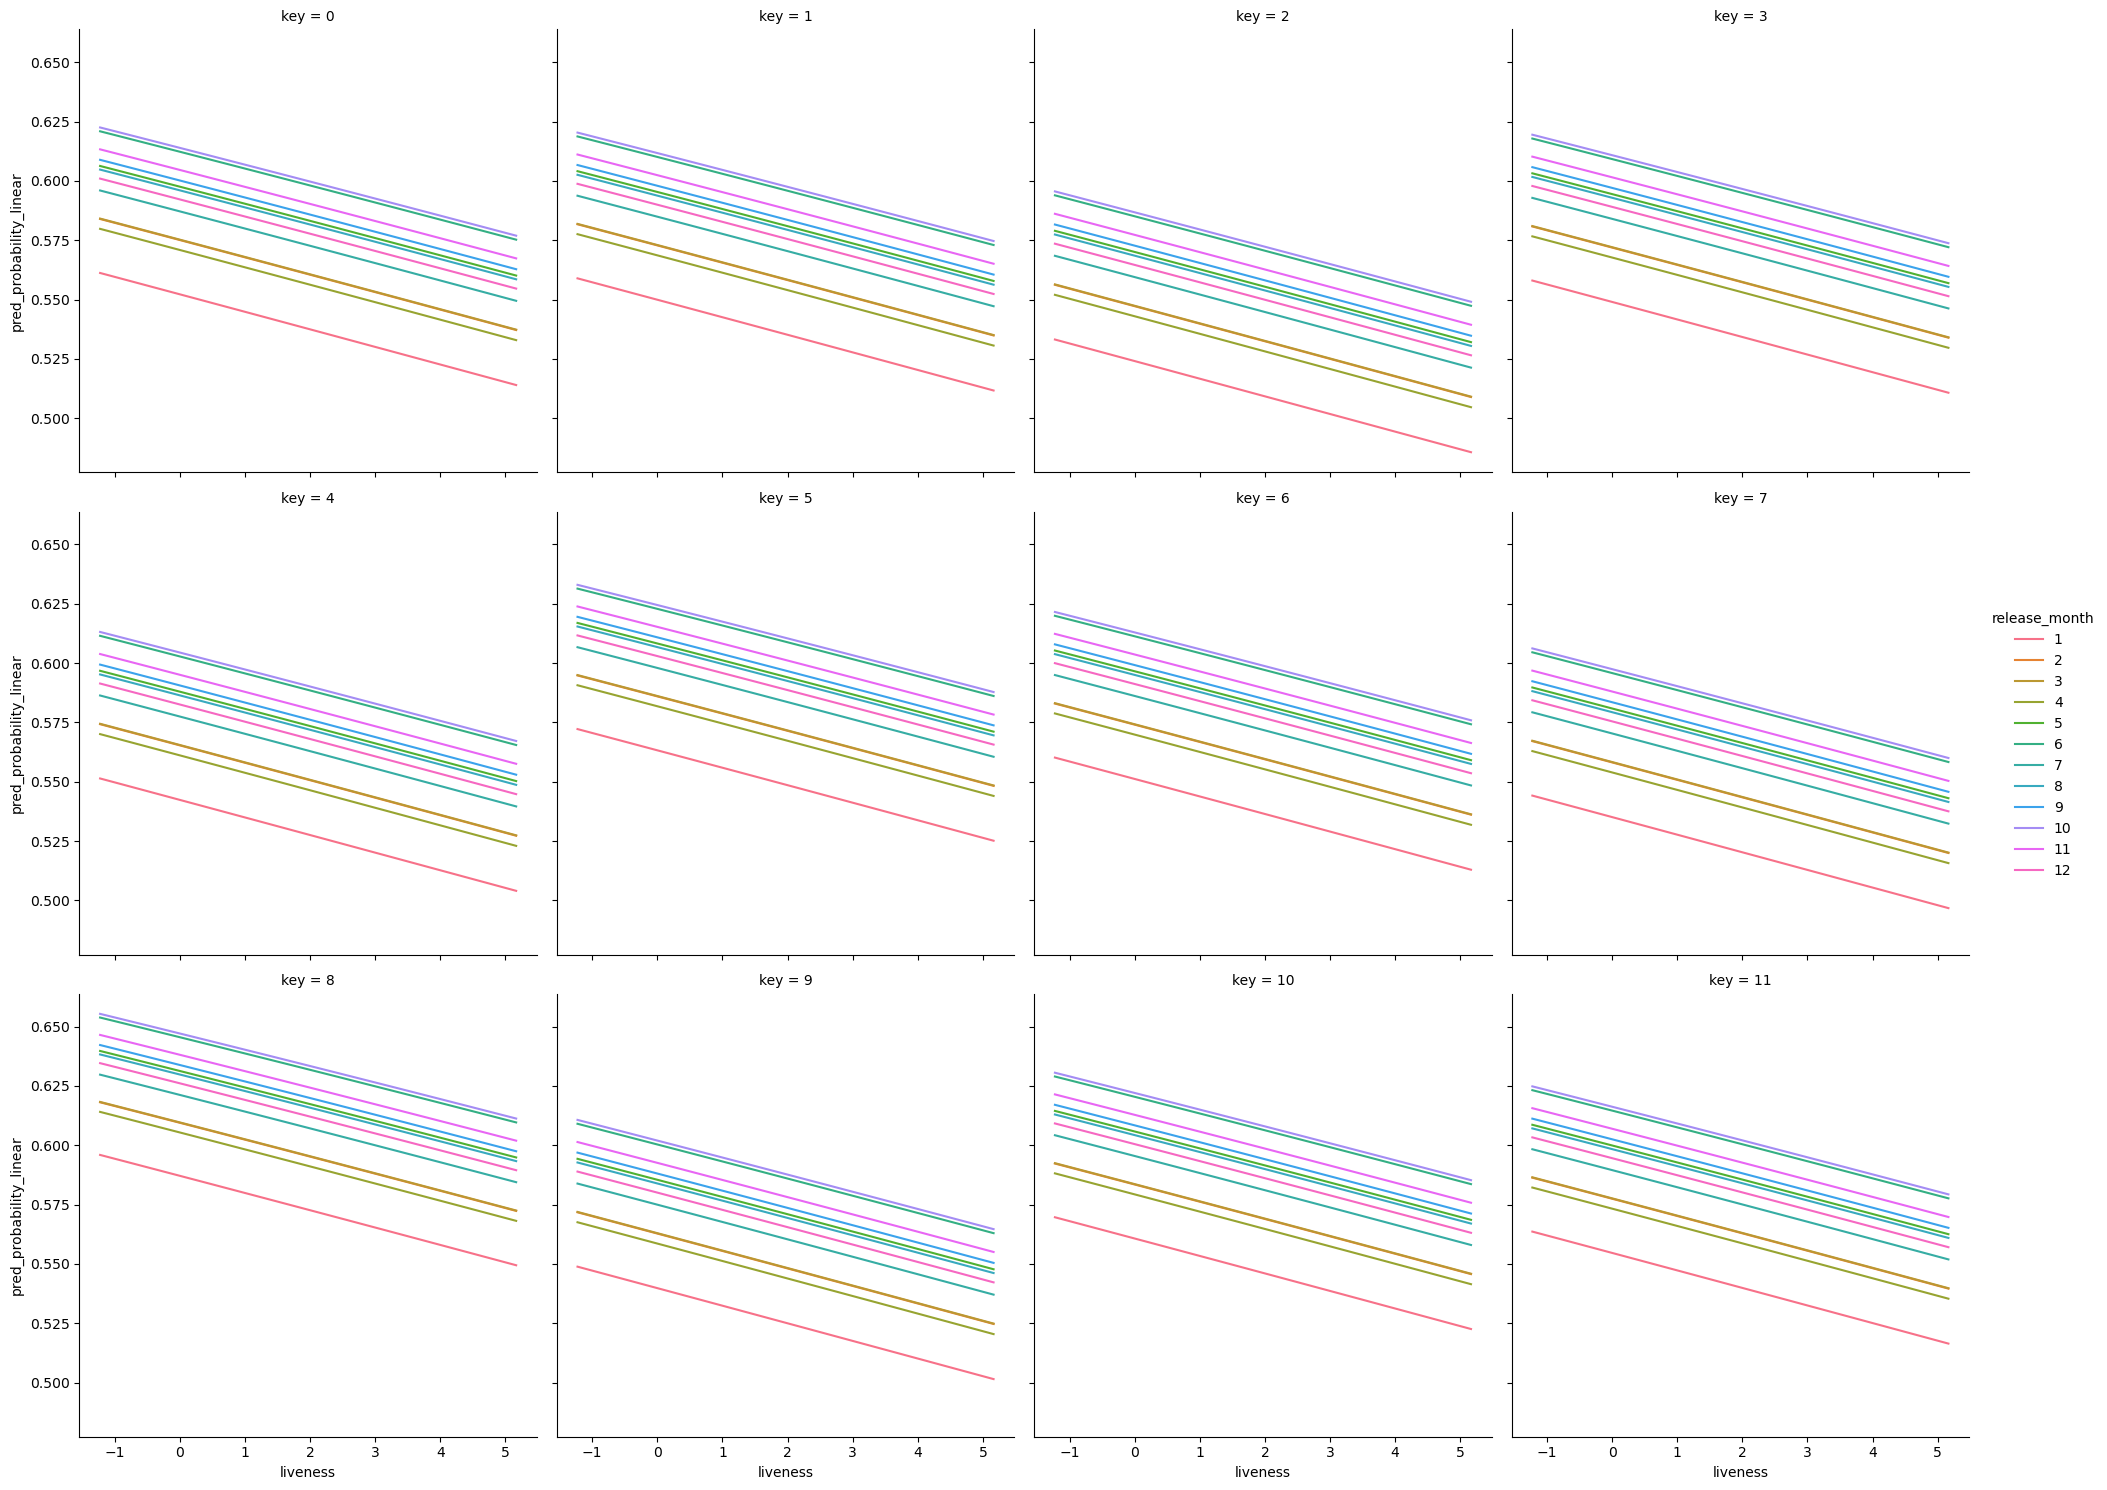

In [19]:
sns.relplot(data=viz_grid, x='liveness', y='pred_probability_linear', hue='release_month', col='key',
           kind='line', estimator=None, units='release_month',
           col_wrap=4)

plt.show()

So as `liveness` increases, probability decreases.

It looks like certain keys have higher predicted probabilities, and the same with months.

## Best Training Model

In [20]:
viz_grid['pred_probability_best'] = fit_best.predict(input_grid)

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


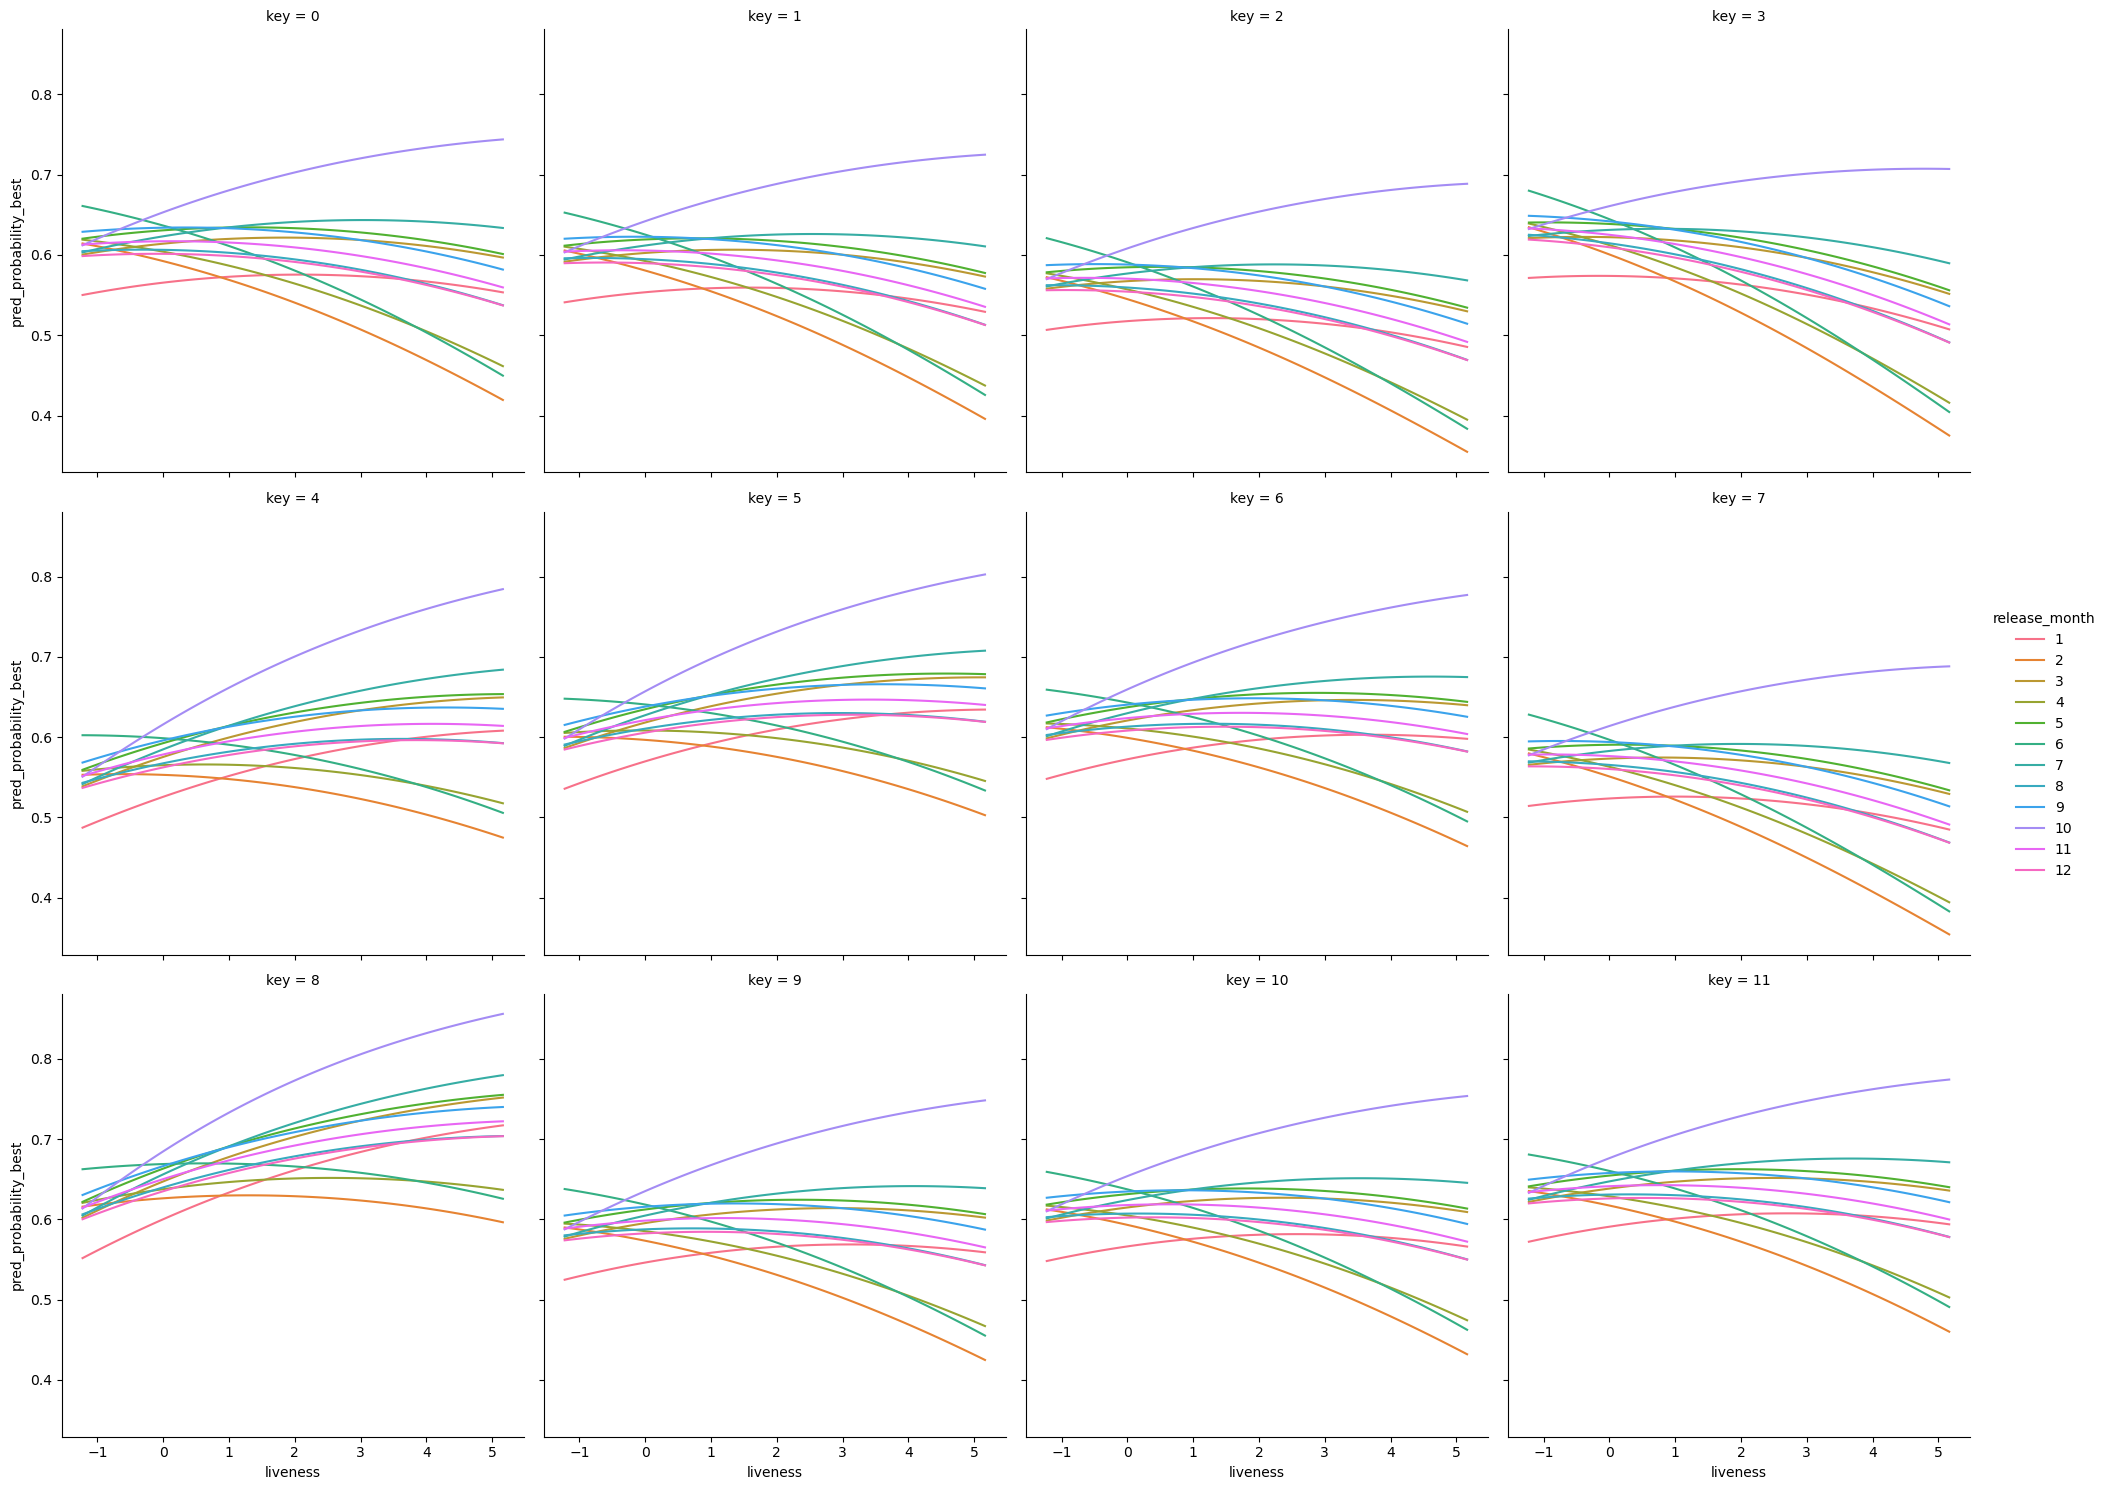

In [21]:
sns.relplot(data=viz_grid, x='liveness', y='pred_probability_best', hue='release_month', col='key',
           kind='line', estimator=None, units='release_month',
           col_wrap=4)

plt.show()

The relationship between liveness and predicted popularity in this model is very different. For some release_month values, the slope is positve and some is negative. When you look from key to key, you can also see how the slopes can change from negative to positive as with songs released in June/July where in key 3 the slope is negative, while in key 5 it is positive.